# IR Conversion Uplift Waterfall Charts

This notebook generates waterfall charts showing the cumulative impact of various initiatives on IR conversion rate improvement.

**Key distinction:**
- **Incremental Uplift** (yellow): Real business impact that drives additional conversions and revenue
- **Baseline Correction** (gray): Measurement adjustment that improves the conversion rate metric but doesn't generate new conversions

**Note:** Incremental initiatives start after the baseline's HIGH estimate to avoid visual overlap with the baseline uncertainty range.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Hertz brand colors
HERTZ_YELLOW = '#F5C400'
HERTZ_CHARCOAL = '#1A1A1A'
HERTZ_DARK_GRAY = '#6E6E6E'
HERTZ_LIGHT_GRAY = '#E6E6E6'

# Set default styling
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = HERTZ_LIGHT_GRAY
plt.rcParams['axes.labelcolor'] = HERTZ_CHARCOAL
plt.rcParams['xtick.color'] = HERTZ_CHARCOAL
plt.rcParams['ytick.color'] = HERTZ_CHARCOAL

In [2]:
# Load the data
xlsx = pd.ExcelFile('../data/raw/260126_IR-upliftsizing_v2.xlsx', engine='openpyxl')
df = pd.read_excel(xlsx, sheet_name='Summary', header=None)

# Extract initiative data (rows 19-31, row 18 is headers)
# Columns: 0=#, 1=Initiative, 6=Category, 7=Uplift Lever, 10-11=Uplift(pp), 12-13=Uplift(EBITDA $m), 14-15=Revenue($m)
data = df.iloc[19:32, [0, 1, 6, 7, 10, 11, 12, 13, 14, 15]].copy()
data.columns = ['#', 'Initiative', 'Category', 'Uplift_Lever', 'Uplift_pp_LOW', 'Uplift_pp_HIGH', 'EBITDA_LOW', 'EBITDA_HIGH', 'REVENUE_LOW', 'REVENUE_HIGH']
data = data.reset_index(drop=True)

# Convert uplift values to percentage points (multiply by 100)
data['Uplift_pp_LOW'] = pd.to_numeric(data['Uplift_pp_LOW'], errors='coerce') * 100
data['Uplift_pp_HIGH'] = pd.to_numeric(data['Uplift_pp_HIGH'], errors='coerce') * 100

# Convert EBITDA to numeric ($m)
data['EBITDA_LOW'] = pd.to_numeric(data['EBITDA_LOW'], errors='coerce')
data['EBITDA_HIGH'] = pd.to_numeric(data['EBITDA_HIGH'], errors='coerce')

# Convert Revenue to numeric ($m)
data['REVENUE_LOW'] = pd.to_numeric(data['REVENUE_LOW'], errors='coerce')
data['REVENUE_HIGH'] = pd.to_numeric(data['REVENUE_HIGH'], errors='coerce')

# Mark baseline correction initiative (no EBITDA/Revenue impact)
data['is_baseline'] = data['#'].astype(str) == '1'

print(data[['#', 'Uplift_Lever', 'Uplift_pp_LOW', 'Uplift_pp_HIGH', 'EBITDA_LOW', 'EBITDA_HIGH', 'REVENUE_LOW', 'REVENUE_HIGH', 'is_baseline']].to_string())

        #                     Uplift_Lever  Uplift_pp_LOW  Uplift_pp_HIGH  EBITDA_LOW  EBITDA_HIGH  REVENUE_LOW  REVENUE_HIGH  is_baseline
0       1              Baseline Adjustment       2.191329        3.804335         NaN          NaN          NaN           NaN         True
1       2  Higher Branch Contact (Inbound)       0.375747        0.751493    0.375747     0.751493     1.014516      2.029032        False
2       3            Higher HRD Conversion       0.173011        0.288352    0.173011     0.288352     0.467130      0.778550        False
3       4  Higher Branch Contact (Inbound)       0.767086        1.111431    0.767086     1.111431     2.071132      3.000863        False
4       5            Higher MMR Completion       0.614164        1.401555    0.614164     1.401555     1.658244      3.784198        False
5       6            Higher MMR Completion       0.634069        0.887696    0.634069     0.887696     1.711985      2.396779        False
6     5-6            Higher

## Chart 1: Vertical Waterfall by Uplift Lever

In [3]:
# Aggregate data by Uplift Lever
lever_data = data.groupby('Uplift_Lever').agg({
    'Uplift_pp_LOW': 'sum',
    'Uplift_pp_HIGH': 'sum',
    'EBITDA_LOW': 'sum',
    'EBITDA_HIGH': 'sum',
    'REVENUE_LOW': 'sum',
    'REVENUE_HIGH': 'sum',
    '#': lambda x: ', '.join(x.astype(str)),
    'is_baseline': 'any'
}).reset_index()

# Define the order and display names for levers (updated to match new Uplift_Lever names)
lever_order = [
    ('Baseline Adjustment', 'Baseline\nAdjustment', '(1)'),
    ('Higher Branch Contact (Inbound)', 'Higher Branch\nContact', '(2, 4)'),
    ('Higher HRD Conversion', 'Higher HRD\nConversion', '(3)'),
    ('Higher MMR Completion', 'Higher MMR\nCompletion', '(5, 6, 5-6)'),
    ('Faster Counter Contact', 'Faster Counter\nContact', '(7, 8)'),
    ('Improved Branch Conversion', 'Improved Branch\nConversion', '(9, 10, 11)'),
    ('Reduced Competitor Flips', 'Reduced\nCompetitor Flips', '(12-13)')
]

# Build ordered data
ordered_levers = []
for lever_name, display_name, initiatives in lever_order:
    row = lever_data[lever_data['Uplift_Lever'] == lever_name]
    if not row.empty:
        ordered_levers.append({
            'lever': display_name,
            'initiatives': initiatives,
            'low': row['Uplift_pp_LOW'].values[0],
            'high': row['Uplift_pp_HIGH'].values[0],
            'ebitda_low': row['EBITDA_LOW'].values[0],
            'ebitda_high': row['EBITDA_HIGH'].values[0],
            'revenue_low': row['REVENUE_LOW'].values[0] if not pd.isna(row['REVENUE_LOW'].values[0]) else 0,
            'revenue_high': row['REVENUE_HIGH'].values[0] if not pd.isna(row['REVENUE_HIGH'].values[0]) else 0,
            'is_baseline': row['is_baseline'].values[0]
        })

lever_df = pd.DataFrame(ordered_levers)
lever_df['delta'] = lever_df['high'] - lever_df['low']
print(lever_df)

                         lever  initiatives       low      high  ebitda_low  \
0         Baseline\nAdjustment          (1)  2.191329  3.804335    0.000000   
1       Higher Branch\nContact       (2, 4)  1.142833  1.862924    1.142833   
2       Higher HRD\nConversion          (3)  0.173011  0.288352    0.173011   
3       Higher MMR\nCompletion  (5, 6, 5-6)  1.401832  2.779980    1.401832   
4      Faster Counter\nContact       (7, 8)  0.898678  1.348017    0.898678   
5  Improved Branch\nConversion  (9, 10, 11)  1.095557  1.825929    1.095557   
6    Reduced\nCompetitor Flips      (12-13)  0.495000  1.237500    0.495000   

   ebitda_high  revenue_low  revenue_high  is_baseline     delta  
0     0.000000     0.000000      0.000000         True  1.613006  
1     1.862924     3.085648      5.029895        False  0.720091  
2     0.288352     0.467130      0.778550        False  0.115341  
3     2.779980     3.784946      7.505945        False  1.378148  
4     1.348017     2.426431     

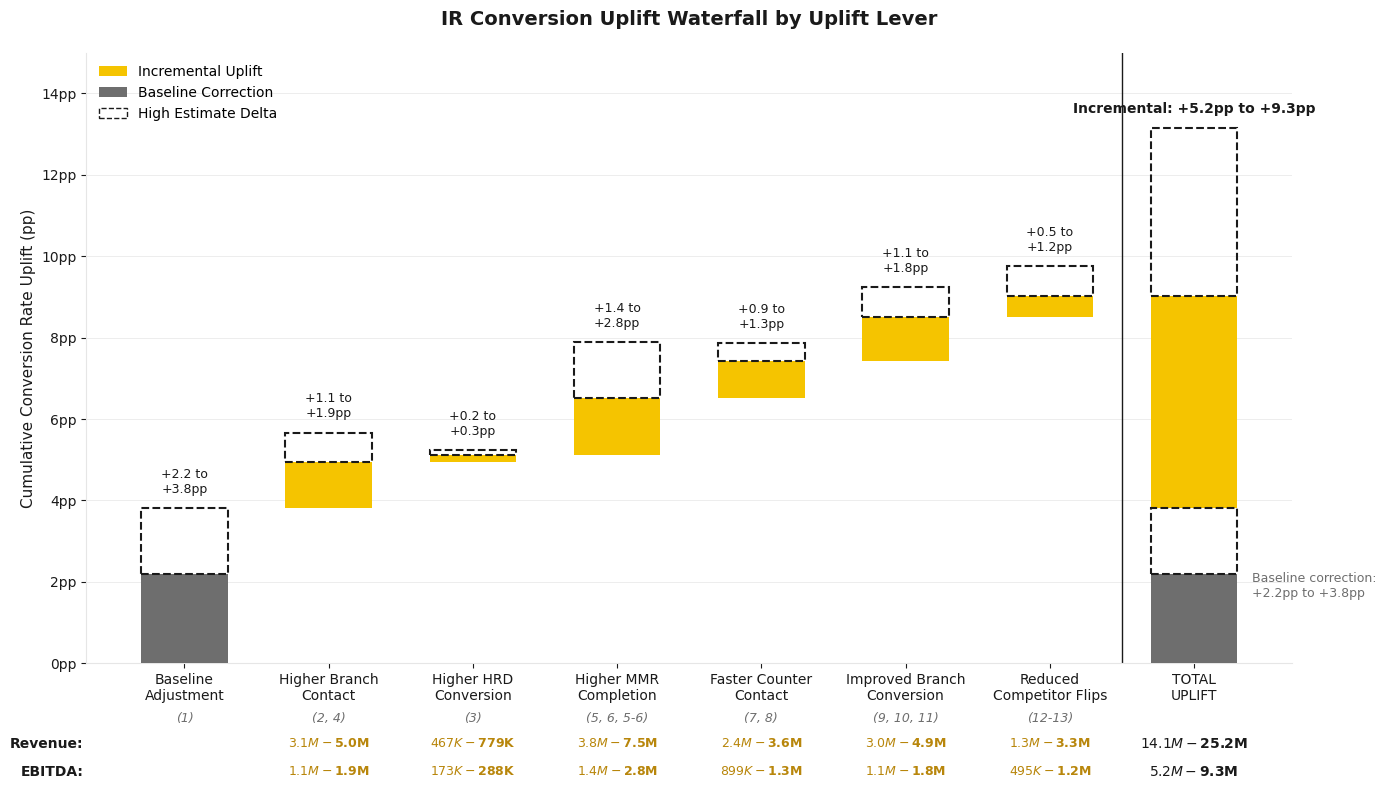


=== VALUE VERIFICATION ===
Revenue and EBITDA values from spreadsheet (in $m):

Individual incremental levers:
  Higher Branch Contact: Revenue $3.1M - $5.0M | EBITDA $1.1M - $1.9M
  Higher HRD Conversion: Revenue $467K - $779K | EBITDA $173K - $288K
  Higher MMR Completion: Revenue $3.8M - $7.5M | EBITDA $1.4M - $2.8M
  Faster Counter Contact: Revenue $2.4M - $3.6M | EBITDA $899K - $1.3M
  Improved Branch Conversion: Revenue $3.0M - $4.9M | EBITDA $1.1M - $1.8M
  Reduced Competitor Flips: Revenue $1.3M - $3.3M | EBITDA $495K - $1.2M

Total Revenue:  $14.1M - $25.2M
Total EBITDA:   $5.2M - $9.3M


In [4]:
fig, ax = plt.subplots(figsize=(14, 8))

n_bars = len(lever_df) + 1  # +1 for total
x = np.arange(n_bars)
bar_width = 0.6

# Helper function to format currency (values are in $m)
def format_currency(val_m):
    if val_m >= 1:
        return f"${val_m:.1f}M"
    elif val_m >= 0.001:
        return f"${val_m*1000:.0f}K"
    else:
        return f"${val_m*1000000:.0f}"

# Calculate totals
baseline_low = lever_df[lever_df['is_baseline']]['low'].sum()
baseline_high = lever_df[lever_df['is_baseline']]['high'].sum()
real_low = lever_df[~lever_df['is_baseline']]['low'].sum()
real_high = lever_df[~lever_df['is_baseline']]['high'].sum()

# EBITDA totals (from spreadsheet, in $m)
real_ebitda_low = lever_df[~lever_df['is_baseline']]['ebitda_low'].sum()
real_ebitda_high = lever_df[~lever_df['is_baseline']]['ebitda_high'].sum()

# Revenue totals (from spreadsheet, in $m)
real_revenue_low = lever_df[~lever_df['is_baseline']]['revenue_low'].sum()
real_revenue_high = lever_df[~lever_df['is_baseline']]['revenue_high'].sum()

# Calculate cumulative positions
# KEY: Initiative 2 starts at baseline's HIGH, others stack on LOW
bottoms = []
cumulative = 0
for i, row in lever_df.iterrows():
    if i == 0:  # First bar (baseline) starts at 0
        bottoms.append(0)
        cumulative = row['high']  # Next bar starts at baseline's HIGH
    else:
        bottoms.append(cumulative)
        cumulative += row['low']  # Subsequent bars stack on LOW

bottoms.append(0)  # Total bar starts at 0

# Draw bars for each lever
for i, row in lever_df.iterrows():
    bar_color = HERTZ_DARK_GRAY if row['is_baseline'] else HERTZ_YELLOW
    
    ax.bar(i, row['low'], bar_width, bottom=bottoms[i], 
           color=bar_color, edgecolor='none', zorder=3)
    
    if row['delta'] > 0.01:
        rect = mpatches.FancyBboxPatch(
            (i - bar_width/2, bottoms[i] + row['low']), 
            bar_width, row['delta'],
            boxstyle='square,pad=0',
            facecolor='none', 
            edgecolor=HERTZ_CHARCOAL,
            linestyle='--',
            linewidth=1.5,
            zorder=4
        )
        ax.add_patch(rect)

# Total bar - gray baseline with dashed range, then yellow incremental on top
# Gray solid: 0 to baseline_low
ax.bar(n_bars - 1, baseline_low, bar_width, bottom=0, 
       color=HERTZ_DARK_GRAY, edgecolor='none', zorder=3)

# Gray dashed: baseline_low to baseline_high
baseline_delta = baseline_high - baseline_low
rect = mpatches.FancyBboxPatch(
    (n_bars - 1 - bar_width/2, baseline_low), 
    bar_width, baseline_delta,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Yellow solid: starts at baseline_high, height = real_low
ax.bar(n_bars - 1, real_low, bar_width, bottom=baseline_high, 
       color=HERTZ_YELLOW, edgecolor='none', zorder=3)

# Yellow dashed: real uplift delta at top
real_delta = real_high - real_low
rect = mpatches.FancyBboxPatch(
    (n_bars - 1 - bar_width/2, baseline_high + real_low), 
    bar_width, real_delta,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Add vertical line before total
ax.axvline(x=n_bars - 1.5, color=HERTZ_CHARCOAL, linewidth=1, zorder=2)

# Add labels above bars
for i, row in lever_df.iterrows():
    if row['delta'] > 0.01:
        label = f"+{row['low']:.1f} to\n+{row['high']:.1f}pp"
        y_pos = bottoms[i] + row['high'] + 0.3
    else:
        label = f"+{row['low']:.2f}pp"
        y_pos = bottoms[i] + row['low'] + 0.3
    ax.text(i, y_pos, label, ha='center', va='bottom', fontsize=9, color=HERTZ_CHARCOAL)

# Total labels
ax.text(n_bars - 1, baseline_high + real_high + 0.3, 
        f"Incremental: +{real_low:.1f}pp to +{real_high:.1f}pp", 
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=HERTZ_CHARCOAL)

ax.text(n_bars - 1 + bar_width/2 + 0.1, baseline_high/2, 
        f"Baseline correction:\n+{baseline_low:.1f}pp to +{baseline_high:.1f}pp", 
        ha='left', va='center', fontsize=9, color=HERTZ_DARK_GRAY)

# X-axis labels
labels = list(lever_df['lever']) + ['TOTAL\nUPLIFT']
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)

# Add initiative numbers below x-axis labels
initiatives = list(lever_df['initiatives']) + ['']
for i, init in enumerate(initiatives):
    if init:
        ax.text(i, -1.2, init, ha='center', va='top', fontsize=9, 
                color=HERTZ_DARK_GRAY, style='italic')

# Y-positions for Revenue and EBITDA rows
revenue_y = -1.8
ebitda_y = -2.5

# Add "Revenue:" label on the left
ax.text(-0.7, revenue_y, 'Revenue:', ha='right', va='top', fontsize=10, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Add "EBITDA:" label on the left
ax.text(-0.7, ebitda_y, 'EBITDA:', ha='right', va='top', fontsize=10, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Add Revenue values below initiative numbers (only for incremental, not baseline)
for i, row in lever_df.iterrows():
    if row['is_baseline']:
        continue
    
    if row['revenue_low'] != row['revenue_high']:
        revenue_label = f"{format_currency(row['revenue_low'])} - {format_currency(row['revenue_high'])}"
    else:
        revenue_label = format_currency(row['revenue_low'])
    
    ax.text(i, revenue_y, revenue_label, ha='center', va='top', fontsize=9, 
            color='#B8860B', fontweight='bold')

# Add total Revenue below TOTAL UPLIFT
total_revenue_label = f"{format_currency(real_revenue_low)} - {format_currency(real_revenue_high)}"
ax.text(n_bars - 1, revenue_y, total_revenue_label, ha='center', va='top', fontsize=10, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Add EBITDA values below Revenue (only for incremental, not baseline)
for i, row in lever_df.iterrows():
    if row['is_baseline']:
        continue
    
    if row['ebitda_low'] != row['ebitda_high']:
        value_label = f"{format_currency(row['ebitda_low'])} - {format_currency(row['ebitda_high'])}"
    else:
        value_label = format_currency(row['ebitda_low'])
    
    ax.text(i, ebitda_y, value_label, ha='center', va='top', fontsize=9, 
            color='#B8860B', fontweight='bold')

# Add total EBITDA below TOTAL UPLIFT
total_ebitda_label = f"{format_currency(real_ebitda_low)} - {format_currency(real_ebitda_high)}"
ax.text(n_bars - 1, ebitda_y, total_ebitda_label, ha='center', va='top', fontsize=10, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Y-axis
ax.set_ylabel('Cumulative Conversion Rate Uplift (pp)', fontsize=11, color=HERTZ_CHARCOAL)
ax.set_ylim(0, 15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}pp'))

# Grid
ax.yaxis.grid(True, color=HERTZ_LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(HERTZ_LIGHT_GRAY)
ax.spines['bottom'].set_color(HERTZ_LIGHT_GRAY)

# Title
ax.set_title('IR Conversion Uplift Waterfall by Uplift Lever', 
             fontsize=14, fontweight='bold', color=HERTZ_CHARCOAL, pad=20)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=HERTZ_YELLOW, edgecolor='none', label='Incremental Uplift'),
    mpatches.Patch(facecolor=HERTZ_DARK_GRAY, edgecolor='none', label='Baseline Correction'),
    mpatches.Patch(facecolor='none', edgecolor=HERTZ_CHARCOAL, linestyle='--', label='High Estimate Delta')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('../Charts/ir_uplift_waterfall_vertical.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Verification: Print breakdown to confirm totals match
print("\n=== VALUE VERIFICATION ===")
print("Revenue and EBITDA values from spreadsheet (in $m):")
print()
print("Individual incremental levers:")
running_rev_low = 0
running_rev_high = 0
running_ebitda_low = 0
running_ebitda_high = 0
for i, row in lever_df.iterrows():
    if not row['is_baseline']:
        running_rev_low += row['revenue_low']
        running_rev_high += row['revenue_high']
        running_ebitda_low += row['ebitda_low']
        running_ebitda_high += row['ebitda_high']
        lever_name = row['lever'].replace(chr(10), ' ')
        print(f"  {lever_name}: Revenue {format_currency(row['revenue_low'])} - {format_currency(row['revenue_high'])} | EBITDA {format_currency(row['ebitda_low'])} - {format_currency(row['ebitda_high'])}")

print()
print(f"Total Revenue:  {format_currency(running_rev_low)} - {format_currency(running_rev_high)}")
print(f"Total EBITDA:   {format_currency(running_ebitda_low)} - {format_currency(running_ebitda_high)}")

## Chart 2: Horizontal Waterfall by Initiative

In [5]:
# Create display labels (updated initiative names from spreadsheet)
name_mapping = {
    '1': '1. Remove Noise Data',
    '2': '2. Update IVR Call Tree',
    '3': '3. HRD Verbiage Update',
    '4': '4. HRD Warm Transfer SOP',
    '5': '5. MMR Page 1 Reminder',
    '6': '6. MMR Page 2 UX Improvements',
    '5-6': '5-6. MMR Interaction Effect',
    '7': '7. Branch: HLES Queue Check',
    '8': '8. Branch: Phone Discipline',
    '9': '9. Branch: Leadership Cascade',
    '10': '10. Branch: Weekly Lead Reviews',
    '11': '11. Branch: Escalation Path',
    '12-13': '12-13. Bodyshop Outreach'
}

data['Label'] = data['#'].astype(str).map(name_mapping)
data['delta'] = data['Uplift_pp_HIGH'] - data['Uplift_pp_LOW']

print(data[['Label', 'Uplift_pp_LOW', 'Uplift_pp_HIGH', 'delta', 'EBITDA_LOW', 'EBITDA_HIGH', 'is_baseline']].to_string())

                              Label  Uplift_pp_LOW  Uplift_pp_HIGH     delta  EBITDA_LOW  EBITDA_HIGH  is_baseline
0              1. Remove Noise Data       2.191329        3.804335  1.613006         NaN          NaN         True
1           2. Update IVR Call Tree       0.375747        0.751493  0.375747    0.375747     0.751493        False
2            3. HRD Verbiage Update       0.173011        0.288352  0.115341    0.173011     0.288352        False
3          4. HRD Warm Transfer SOP       0.767086        1.111431  0.344345    0.767086     1.111431        False
4            5. MMR Page 1 Reminder       0.614164        1.401555  0.787390    0.614164     1.401555        False
5     6. MMR Page 2 UX Improvements       0.634069        0.887696  0.253627    0.634069     0.887696        False
6       5-6. MMR Interaction Effect       0.153599        0.490729  0.337130    0.153599     0.490729        False
7       7. Branch: HLES Queue Check       0.449339        0.674009  0.224670    

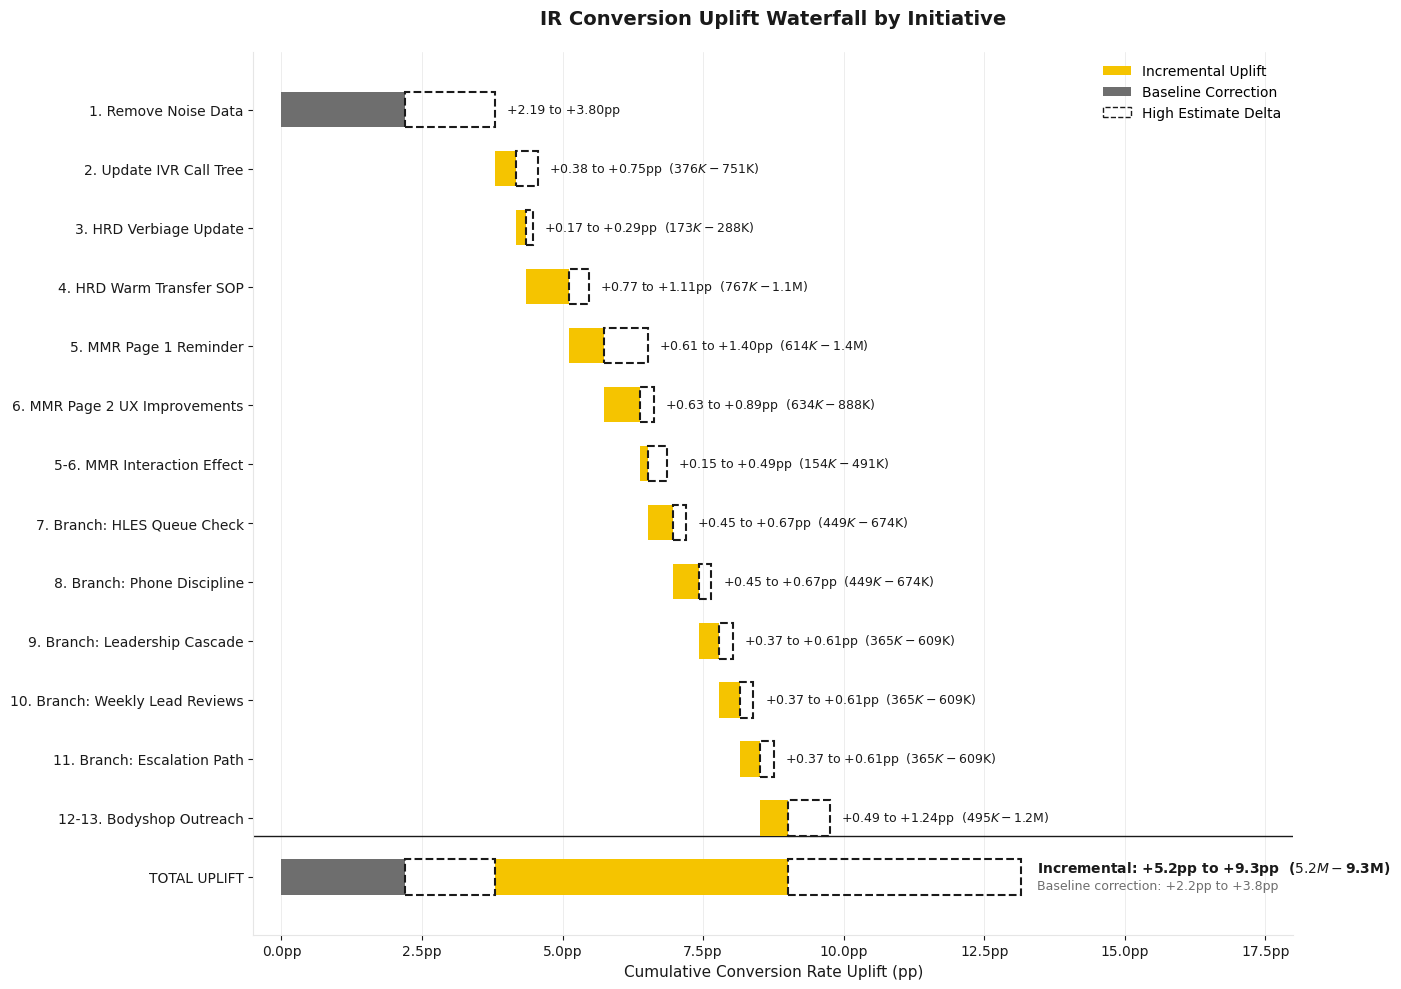


=== VALUE VERIFICATION (Chart 2) ===
EBITDA values from spreadsheet (in $m):

Individual incremental initiatives:
  2. Update IVR Call Tree: $376K - $751K
  3. HRD Verbiage Update: $173K - $288K
  4. HRD Warm Transfer SOP: $767K - $1.1M
  5. MMR Page 1 Reminder: $614K - $1.4M
  6. MMR Page 2 UX Improvements: $634K - $888K
  5-6. MMR Interaction Effect: $154K - $491K
  7. Branch: HLES Queue Check: $449K - $674K
  8. Branch: Phone Discipline: $449K - $674K
  9. Branch: Leadership Cascade: $365K - $609K
  10. Branch: Weekly Lead Reviews: $365K - $609K
  11. Branch: Escalation Path: $365K - $609K
  12-13. Bodyshop Outreach: $495K - $1.2M

Sum of incremental initiatives: $5.2M - $9.3M
Total shown on chart:           $5.2M - $9.3M
Match: True


In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

n_bars = len(data) + 1  # +1 for total
bar_height = 0.6

# Helper function to format currency (values are in $m)
def format_currency(val_m):
    if pd.isna(val_m):
        return ""
    if val_m >= 1:
        return f"${val_m:.1f}M"
    elif val_m >= 0.001:
        return f"${val_m*1000:.0f}K"
    else:
        return f"${val_m*1000000:.0f}"

# Calculate totals
baseline_low = data[data['is_baseline']]['Uplift_pp_LOW'].sum()
baseline_high = data[data['is_baseline']]['Uplift_pp_HIGH'].sum()
real_low = data[~data['is_baseline']]['Uplift_pp_LOW'].sum()
real_high = data[~data['is_baseline']]['Uplift_pp_HIGH'].sum()

# EBITDA totals (from spreadsheet, in $m)
real_ebitda_low = data[~data['is_baseline']]['EBITDA_LOW'].sum()
real_ebitda_high = data[~data['is_baseline']]['EBITDA_HIGH'].sum()

# Calculate cumulative positions
# KEY: Initiative 2 starts at baseline's HIGH, others stack on LOW
lefts = []
cumulative = 0
for i, row in data.iterrows():
    if row['is_baseline']:  # First initiative (baseline) starts at 0
        lefts.append(0)
        cumulative = row['Uplift_pp_HIGH']  # Next starts at baseline's HIGH
    else:
        lefts.append(cumulative)
        cumulative += row['Uplift_pp_LOW']  # Subsequent stack on LOW

lefts.append(0)  # Total bar starts at 0

# Y positions (initiatives from top, total at bottom with gap)
y_positions = list(range(n_bars - 1, 0, -1)) + [0]

# Draw bars for each initiative
for i, (idx, row) in enumerate(data.iterrows()):
    y_pos = y_positions[i]
    bar_color = HERTZ_DARK_GRAY if row['is_baseline'] else HERTZ_YELLOW
    
    ax.barh(y_pos, row['Uplift_pp_LOW'], bar_height, left=lefts[i], 
            color=bar_color, edgecolor='none', zorder=3)
    
    if row['delta'] > 0.01:
        rect = mpatches.FancyBboxPatch(
            (lefts[i] + row['Uplift_pp_LOW'], y_pos - bar_height/2), 
            row['delta'], bar_height,
            boxstyle='square,pad=0',
            facecolor='none', 
            edgecolor=HERTZ_CHARCOAL,
            linestyle='--',
            linewidth=1.5,
            zorder=4
        )
        ax.add_patch(rect)

# Total bar - gray baseline with dashed range, then yellow incremental
# Gray solid: 0 to baseline_low
ax.barh(0, baseline_low, bar_height, left=0, 
        color=HERTZ_DARK_GRAY, edgecolor='none', zorder=3)

# Gray dashed: baseline_low to baseline_high
baseline_delta = baseline_high - baseline_low
rect = mpatches.FancyBboxPatch(
    (baseline_low, 0 - bar_height/2), 
    baseline_delta, bar_height,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Yellow solid: starts at baseline_high, width = real_low
ax.barh(0, real_low, bar_height, left=baseline_high, 
        color=HERTZ_YELLOW, edgecolor='none', zorder=3)

# Yellow dashed: real uplift delta at the end
real_delta = real_high - real_low
rect = mpatches.FancyBboxPatch(
    (baseline_high + real_low, 0 - bar_height/2), 
    real_delta, bar_height,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Add horizontal line above total
ax.axhline(y=0.7, color=HERTZ_CHARCOAL, linewidth=1, zorder=2)

# Add labels to the right of bars (with dollar values for incremental only)
for i, (idx, row) in enumerate(data.iterrows()):
    y_pos = y_positions[i]
    
    if row['is_baseline']:
        # Baseline: no dollar value
        if row['delta'] > 0.01:
            label = f"+{row['Uplift_pp_LOW']:.2f} to +{row['Uplift_pp_HIGH']:.2f}pp"
            x_pos = lefts[i] + row['Uplift_pp_HIGH'] + 0.2
        else:
            label = f"+{row['Uplift_pp_LOW']:.2f}pp"
            x_pos = lefts[i] + row['Uplift_pp_LOW'] + 0.2
        ax.text(x_pos, y_pos, label, ha='left', va='center', fontsize=9, color=HERTZ_CHARCOAL)
    else:
        # Incremental: include dollar value from spreadsheet
        ebitda_low = row['EBITDA_LOW']
        ebitda_high = row['EBITDA_HIGH']
        
        if row['delta'] > 0.01:
            label = f"+{row['Uplift_pp_LOW']:.2f} to +{row['Uplift_pp_HIGH']:.2f}pp  ({format_currency(ebitda_low)} - {format_currency(ebitda_high)})"
            x_pos = lefts[i] + row['Uplift_pp_HIGH'] + 0.2
        else:
            label = f"+{row['Uplift_pp_LOW']:.2f}pp  ({format_currency(ebitda_low)})"
            x_pos = lefts[i] + row['Uplift_pp_LOW'] + 0.2
        ax.text(x_pos, y_pos, label, ha='left', va='center', fontsize=9, color=HERTZ_CHARCOAL)

# Total labels (only incremental value, not baseline)
ax.text(baseline_high + real_high + 0.3, 0.15, 
        f"Incremental: +{real_low:.1f}pp to +{real_high:.1f}pp  ({format_currency(real_ebitda_low)} - {format_currency(real_ebitda_high)})", 
        ha='left', va='center', fontsize=10, fontweight='bold', color=HERTZ_CHARCOAL)
ax.text(baseline_high + real_high + 0.3, -0.15, 
        f"Baseline correction: +{baseline_low:.1f}pp to +{baseline_high:.1f}pp", 
        ha='left', va='center', fontsize=9, color=HERTZ_DARK_GRAY)

# Y-axis labels
labels = list(data['Label']) + ['TOTAL UPLIFT']
ax.set_yticks(y_positions)
ax.set_yticklabels([labels[i] for i in range(len(data))] + ['TOTAL UPLIFT'], fontsize=10)

# X-axis
ax.set_xlabel('Cumulative Conversion Rate Uplift (pp)', fontsize=11, color=HERTZ_CHARCOAL)
ax.set_xlim(-0.5, 18)  # Extended to fit dollar values
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}pp'))

# Grid
ax.xaxis.grid(True, color=HERTZ_LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=1)
ax.yaxis.grid(False)
ax.set_axisbelow(True)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(HERTZ_LIGHT_GRAY)
ax.spines['bottom'].set_color(HERTZ_LIGHT_GRAY)

# Title
ax.set_title('IR Conversion Uplift Waterfall by Initiative', 
             fontsize=14, fontweight='bold', color=HERTZ_CHARCOAL, pad=20)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=HERTZ_YELLOW, edgecolor='none', label='Incremental Uplift'),
    mpatches.Patch(facecolor=HERTZ_DARK_GRAY, edgecolor='none', label='Baseline Correction'),
    mpatches.Patch(facecolor='none', edgecolor=HERTZ_CHARCOAL, linestyle='--', label='High Estimate Delta')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig('../Charts/ir_uplift_waterfall_horizontal.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Verification: Print breakdown to confirm totals match
print("\n=== VALUE VERIFICATION (Chart 2) ===")
print("EBITDA values from spreadsheet (in $m):")
print()
print("Individual incremental initiatives:")
running_low = 0
running_high = 0
for idx, row in data.iterrows():
    if not row['is_baseline']:
        running_low += row['EBITDA_LOW']
        running_high += row['EBITDA_HIGH']
        print(f"  {row['Label']}: {format_currency(row['EBITDA_LOW'])} - {format_currency(row['EBITDA_HIGH'])}")

print()
print(f"Sum of incremental initiatives: {format_currency(running_low)} - {format_currency(running_high)}")
print(f"Total shown on chart:           {format_currency(real_ebitda_low)} - {format_currency(real_ebitda_high)}")
print(f"Match: {abs(running_low - real_ebitda_low) < 0.01 and abs(running_high - real_ebitda_high) < 0.01}")

In [7]:
print(f"Summary:")
print(f"  Baseline correction: +{baseline_low:.2f}pp to +{baseline_high:.2f}pp")
print(f"  Incremental uplift:  +{real_low:.2f}pp to +{real_high:.2f}pp")
print(f"  Incremental EBITDA:  {format_currency(real_ebitda_low)} to {format_currency(real_ebitda_high)}")
print(f"\nCharts saved to:")
print("  - Charts/ir_uplift_waterfall_vertical.png")
print("  - Charts/ir_uplift_waterfall_horizontal.png")

Summary:
  Baseline correction: +2.19pp to +3.80pp
  Incremental uplift:  +5.21pp to +9.34pp
  Incremental EBITDA:  $5.2M to $9.3M

Charts saved to:
  - Charts/ir_uplift_waterfall_vertical.png
  - Charts/ir_uplift_waterfall_horizontal.png


## Chart 3: Vertical Waterfall by Owner

In [8]:
# Aggregate data by Owner (Category column from spreadsheet)
owner_data = data.groupby('Category').agg({
    'Uplift_pp_LOW': 'sum',
    'Uplift_pp_HIGH': 'sum',
    'EBITDA_LOW': 'sum',
    'EBITDA_HIGH': 'sum',
    'REVENUE_LOW': 'sum',
    'REVENUE_HIGH': 'sum',
    '#': lambda x: ', '.join(x.astype(str)),
    'is_baseline': 'any'
}).reset_index()

# Define the order for owners
owner_order = [
    ('Data', 'Data', '(1)'),
    ('Tech', 'Tech', '(5, 6, 5-6)'),
    ('Central / CX', 'Central / CX', '(2, 3, 4)'),
    ('Branch / Ops', 'Branch / Ops', '(7-13)')
]

# Build ordered data
ordered_owners = []
for owner_name, display_name, initiatives in owner_order:
    row = owner_data[owner_data['Category'] == owner_name]
    if not row.empty:
        ordered_owners.append({
            'owner': display_name,
            'initiatives': initiatives,
            'low': row['Uplift_pp_LOW'].values[0],
            'high': row['Uplift_pp_HIGH'].values[0],
            'ebitda_low': row['EBITDA_LOW'].values[0] if not pd.isna(row['EBITDA_LOW'].values[0]) else 0,
            'ebitda_high': row['EBITDA_HIGH'].values[0] if not pd.isna(row['EBITDA_HIGH'].values[0]) else 0,
            'revenue_low': row['REVENUE_LOW'].values[0] if not pd.isna(row['REVENUE_LOW'].values[0]) else 0,
            'revenue_high': row['REVENUE_HIGH'].values[0] if not pd.isna(row['REVENUE_HIGH'].values[0]) else 0,
            'is_baseline': row['is_baseline'].values[0]
        })

owner_df = pd.DataFrame(ordered_owners)
owner_df['delta'] = owner_df['high'] - owner_df['low']
print(owner_df)

          owner  initiatives       low      high  ebitda_low  ebitda_high  \
0          Data          (1)  2.191329  3.804335    0.000000     0.000000   
1          Tech  (5, 6, 5-6)  1.401832  2.779980    1.401832     2.779980   
2  Central / CX    (2, 3, 4)  1.315844  2.151276    1.315844     2.151276   
3  Branch / Ops       (7-13)  2.489236  4.411446    2.489236     4.411446   

   revenue_low  revenue_high  is_baseline     delta  
0     0.000000      0.000000         True  1.613006  
1     3.784946      7.505945        False  1.378148  
2     3.552778      5.808444        False  0.835432  
3     6.720936     11.910905        False  1.922211  


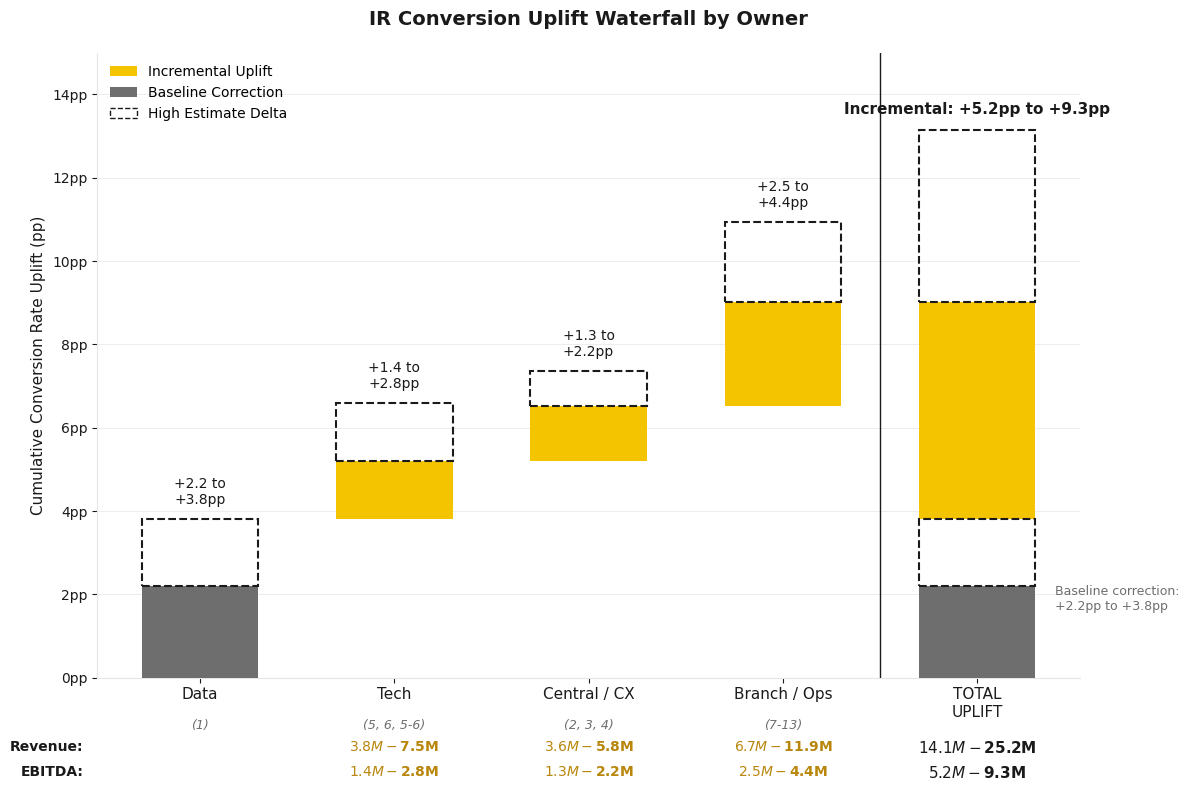


=== UPLIFT BY OWNER ===
  Data: +2.19pp to +3.80pp (Baseline - no Revenue/EBITDA)
  Tech: +1.40pp to +2.78pp | Revenue: $3.8M - $7.5M | EBITDA: $1.4M - $2.8M
  Central / CX: +1.32pp to +2.15pp | Revenue: $3.6M - $5.8M | EBITDA: $1.3M - $2.2M
  Branch / Ops: +2.49pp to +4.41pp | Revenue: $6.7M - $11.9M | EBITDA: $2.5M - $4.4M

Total Incremental: +5.21pp to +9.34pp
Total Revenue:     $14.1M - $25.2M
Total EBITDA:      $5.2M - $9.3M


In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

n_bars = len(owner_df) + 1  # +1 for total
x = np.arange(n_bars)
bar_width = 0.6

# Helper function to format currency (values are in $m)
def format_currency(val_m):
    if val_m >= 1:
        return f"${val_m:.1f}M"
    elif val_m >= 0.001:
        return f"${val_m*1000:.0f}K"
    else:
        return f"${val_m*1000000:.0f}"

# Calculate totals
baseline_low = owner_df[owner_df['is_baseline']]['low'].sum()
baseline_high = owner_df[owner_df['is_baseline']]['high'].sum()
real_low = owner_df[~owner_df['is_baseline']]['low'].sum()
real_high = owner_df[~owner_df['is_baseline']]['high'].sum()

# EBITDA totals
real_ebitda_low = owner_df[~owner_df['is_baseline']]['ebitda_low'].sum()
real_ebitda_high = owner_df[~owner_df['is_baseline']]['ebitda_high'].sum()

# Revenue totals
real_revenue_low = owner_df[~owner_df['is_baseline']]['revenue_low'].sum()
real_revenue_high = owner_df[~owner_df['is_baseline']]['revenue_high'].sum()

# Calculate cumulative positions
bottoms = []
cumulative = 0
for i, row in owner_df.iterrows():
    if i == 0:  # First bar (baseline/Data) starts at 0
        bottoms.append(0)
        cumulative = row['high']  # Next bar starts at baseline's HIGH
    else:
        bottoms.append(cumulative)
        cumulative += row['low']  # Subsequent bars stack on LOW

bottoms.append(0)  # Total bar starts at 0

# Draw bars for each owner
for i, row in owner_df.iterrows():
    bar_color = HERTZ_DARK_GRAY if row['is_baseline'] else HERTZ_YELLOW
    
    ax.bar(i, row['low'], bar_width, bottom=bottoms[i], 
           color=bar_color, edgecolor='none', zorder=3)
    
    if row['delta'] > 0.01:
        rect = mpatches.FancyBboxPatch(
            (i - bar_width/2, bottoms[i] + row['low']), 
            bar_width, row['delta'],
            boxstyle='square,pad=0',
            facecolor='none', 
            edgecolor=HERTZ_CHARCOAL,
            linestyle='--',
            linewidth=1.5,
            zorder=4
        )
        ax.add_patch(rect)

# Total bar - gray baseline with dashed range, then yellow incremental on top
ax.bar(n_bars - 1, baseline_low, bar_width, bottom=0, 
       color=HERTZ_DARK_GRAY, edgecolor='none', zorder=3)

baseline_delta = baseline_high - baseline_low
rect = mpatches.FancyBboxPatch(
    (n_bars - 1 - bar_width/2, baseline_low), 
    bar_width, baseline_delta,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

ax.bar(n_bars - 1, real_low, bar_width, bottom=baseline_high, 
       color=HERTZ_YELLOW, edgecolor='none', zorder=3)

real_delta = real_high - real_low
rect = mpatches.FancyBboxPatch(
    (n_bars - 1 - bar_width/2, baseline_high + real_low), 
    bar_width, real_delta,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Add vertical line before total
ax.axvline(x=n_bars - 1.5, color=HERTZ_CHARCOAL, linewidth=1, zorder=2)

# Add labels above bars
for i, row in owner_df.iterrows():
    if row['delta'] > 0.01:
        label = f"+{row['low']:.1f} to\n+{row['high']:.1f}pp"
        y_pos = bottoms[i] + row['high'] + 0.3
    else:
        label = f"+{row['low']:.2f}pp"
        y_pos = bottoms[i] + row['low'] + 0.3
    ax.text(i, y_pos, label, ha='center', va='bottom', fontsize=10, color=HERTZ_CHARCOAL)

# Total labels
ax.text(n_bars - 1, baseline_high + real_high + 0.3, 
        f"Incremental: +{real_low:.1f}pp to +{real_high:.1f}pp", 
        ha='center', va='bottom', fontsize=11, fontweight='bold', color=HERTZ_CHARCOAL)

ax.text(n_bars - 1 + bar_width/2 + 0.1, baseline_high/2, 
        f"Baseline correction:\n+{baseline_low:.1f}pp to +{baseline_high:.1f}pp", 
        ha='left', va='center', fontsize=9, color=HERTZ_DARK_GRAY)

# X-axis labels
labels = list(owner_df['owner']) + ['TOTAL\nUPLIFT']
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

# Add initiative numbers below x-axis labels
initiatives = list(owner_df['initiatives']) + ['']
for i, init in enumerate(initiatives):
    if init:
        ax.text(i, -1.0, init, ha='center', va='top', fontsize=9, 
                color=HERTZ_DARK_GRAY, style='italic')

# Y-positions for Revenue and EBITDA rows
revenue_y = -1.5
ebitda_y = -2.1

# Add "Revenue:" label on the left
ax.text(-0.6, revenue_y, 'Revenue:', ha='right', va='top', fontsize=10, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Add "EBITDA:" label on the left
ax.text(-0.6, ebitda_y, 'EBITDA:', ha='right', va='top', fontsize=10, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Add Revenue values below initiative numbers (only for incremental, not baseline)
for i, row in owner_df.iterrows():
    if row['is_baseline']:
        continue
    
    if row['revenue_low'] != row['revenue_high']:
        revenue_label = f"{format_currency(row['revenue_low'])} - {format_currency(row['revenue_high'])}"
    else:
        revenue_label = format_currency(row['revenue_low'])
    
    ax.text(i, revenue_y, revenue_label, ha='center', va='top', fontsize=10, 
            color='#B8860B', fontweight='bold')

# Add total Revenue below TOTAL UPLIFT
total_revenue_label = f"{format_currency(real_revenue_low)} - {format_currency(real_revenue_high)}"
ax.text(n_bars - 1, revenue_y, total_revenue_label, ha='center', va='top', fontsize=11, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Add EBITDA values below Revenue (only for incremental, not baseline)
for i, row in owner_df.iterrows():
    if row['is_baseline']:
        continue
    
    if row['ebitda_low'] != row['ebitda_high']:
        value_label = f"{format_currency(row['ebitda_low'])} - {format_currency(row['ebitda_high'])}"
    else:
        value_label = format_currency(row['ebitda_low'])
    
    ax.text(i, ebitda_y, value_label, ha='center', va='top', fontsize=10, 
            color='#B8860B', fontweight='bold')

# Add total EBITDA below TOTAL UPLIFT
total_ebitda_label = f"{format_currency(real_ebitda_low)} - {format_currency(real_ebitda_high)}"
ax.text(n_bars - 1, ebitda_y, total_ebitda_label, ha='center', va='top', fontsize=11, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Y-axis
ax.set_ylabel('Cumulative Conversion Rate Uplift (pp)', fontsize=11, color=HERTZ_CHARCOAL)
ax.set_ylim(0, 15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}pp'))

# Grid
ax.yaxis.grid(True, color=HERTZ_LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(HERTZ_LIGHT_GRAY)
ax.spines['bottom'].set_color(HERTZ_LIGHT_GRAY)

# Title
ax.set_title('IR Conversion Uplift Waterfall by Owner', 
             fontsize=14, fontweight='bold', color=HERTZ_CHARCOAL, pad=20)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=HERTZ_YELLOW, edgecolor='none', label='Incremental Uplift'),
    mpatches.Patch(facecolor=HERTZ_DARK_GRAY, edgecolor='none', label='Baseline Correction'),
    mpatches.Patch(facecolor='none', edgecolor=HERTZ_CHARCOAL, linestyle='--', label='High Estimate Delta')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('../Charts/ir_uplift_waterfall_by_owner.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Verification
print("\n=== UPLIFT BY OWNER ===")
for i, row in owner_df.iterrows():
    if row['is_baseline']:
        print(f"  {row['owner']}: +{row['low']:.2f}pp to +{row['high']:.2f}pp (Baseline - no Revenue/EBITDA)")
    else:
        print(f"  {row['owner']}: +{row['low']:.2f}pp to +{row['high']:.2f}pp | Revenue: {format_currency(row['revenue_low'])} - {format_currency(row['revenue_high'])} | EBITDA: {format_currency(row['ebitda_low'])} - {format_currency(row['ebitda_high'])}")
print()
print(f"Total Incremental: +{real_low:.2f}pp to +{real_high:.2f}pp")
print(f"Total Revenue:     {format_currency(real_revenue_low)} - {format_currency(real_revenue_high)}")
print(f"Total EBITDA:      {format_currency(real_ebitda_low)} - {format_currency(real_ebitda_high)}")